# Tema III. Análisis y Manipulación de Datos con Pandas

## Objetivos de Aprendizaje

Al finalizar este cuaderno serás capaz de:

- Comprender las bases de las estructuras de datos en Pandas (Series y DataFrames)
- Saber cargar, inspeccionar y acceder a los datos
- Limpiar y preparar datos
- Realizar operaciones, agragar y agrupar datos
- Combinar y hacer Reshape de DataFrames
- Trabajar con Series temporales
- Visualizar datos
___

## Introducción y Estructuras Fundamentales (Series y DataFrames)

### Objetivos

* Comprender qué es Pandas y cuáles son sus ventajas frente a la programación imperativa pura con estructuras nativas (lists, dicts).
* Dominar las Series: creación, indexación, vectorización y atributos clave.
* Dominar los DataFrames: creación bidimensional, índices de filas/columnas y gestión de ejes.

### Introducción

Pandas es la librería de código abierto de referencia en Python para la manipulación y el análisis de datos estructurados. Está construida sobre NumPy, lo que significa que ejecuta sus operaciones internas en código C optimizado, ofreciendo un rendimiento muy superior a los bucles for nativos.

- Listas/Diccionarios nativos: Genéricos, heterogéneos y pensados para el control de flujo.
- Pandas: Diseñado para datos tabulares (filas y columnas). Ofrece alineación automática de datos por índice, manejo nativo de valores faltantes y un rendimiento vectorial masivo.

### Series(pd.Series)

Una Serie es una matriz unidimensional homogénea etiquetada capaz de contener cualquier tipo de dato (enteros, cadenas, flotantes, objetos, etc.). Es la columna vertebral de Pandas: un DataFrame no es más que un conjunto de Series agrupadas bajo un índice común.

**Componentes de una Serie:**

- Valores (values): El vector subyacente de datos (array NumPy).
- Índice (index): Las etiquetas asociadas a cada posición (por defecto, enteros de 0 a N-1, pero pueden ser textos o fechas).

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creación básica desde una lista
ventas = pd.Series([100, 250, 300, 450])
print(ventas)

# Creación con índice personalizado
unidades = pd.Series([15, 22, 8], index=["Enero", "Febrero", "Marzo"])
print(unidades)

0    100
1    250
2    300
3    450
dtype: int64
Enero      15
Febrero    22
Marzo       8
dtype: int64


** Atributos y Operaciones Vectorizadas en Series**

A diferencia de las listas de Python, las operaciones con Series se aplican elemento a elemento (vectorización) sin necesidad de bucles:

In [35]:
# Atributos esenciales
print(unidades.index)   # Index(['Enero', 'Febrero', 'Marzo'], dtype='object')
print(unidades.values)  # array([15, 22,  8])
print(unidades.dtype)   # int64

# Operaciones vectorizadas
precios = unidades * 1.21  # Aplica el IVA a todos los elementos a la vez
print(precios)

Index(['Enero', 'Febrero', 'Marzo'], dtype='str')
[15 22  8]
int64
Enero      18.15
Febrero    26.62
Marzo       9.68
dtype: float64


### DataFrames (pd.DataFrame)

Un DataFrame es una estructura de datos bidimensional (tabular) con ejes etiquetados: filas (índice axis=0) y columnas (índice axis=1). Se puede imaginar como una hoja de cálculo de Excel o una tabla SQL programable.

In [36]:
# Creación a partir de un diccionario de listas/Series
datos_alumnos = {
    "Nombre": ["Ana", "Luis", "Carlos", "Marta"],
    "Edad": [20, 22, 21, 23],
    "Nota": [8.5, 6.0, 9.2, 7.8]
}

df = pd.DataFrame(datos_alumnos)
print(df)
#    Nombre  Edad  Nota
# 0     Ana    20   8.5
# 1    Luis    22   6.0
# 2  Carlos    21   9.2
# 3   Marta    23   7.8

   Nombre  Edad  Nota
0     Ana    20   8.5
1    Luis    22   6.0
2  Carlos    21   9.2
3   Marta    23   7.8


**Anatomía y Atributos Básicos del DataFrame**

|Atributo / Propiedad|Descripción|Ejemplo de uso|
|--------------------|-------------------------------------------------|---------------------------------------|
|df.shape|Tupla con las dimensiones (filas, columnas)|df.shape → (4, 3)|
|df.columns|Etiquetas de las columnas (eje 1)|df.columns → ['Nombre', 'Edad', 'Nota']|
|df.index|Etiquetas de las filas (eje 0)|df.index → RangeIndex(start=0, stop=4)|
|df.dtypes|Tipo de dato de cada columna|df.dtypes|
|df.T|Transpone la tabla (intercambia filas y columnas)|df.T|

### Comprensión de los Ejes (axis=0 vs axis=1)

Uno de los conceptos que más confunde a los estudiantes al principio es el uso del parámetro axis.

* axis=0 (Eje de las filas / vertical): Las operaciones se ejecutan hacia abajo, acumulando el resultado para cada columna (ej. calcular la media de cada columna).
* axis=1 (Eje de las columnas / horizontal): Las operaciones se ejecutan a lo ancho, acumulando el resultado para cada fila.

In [37]:
df_notas = pd.DataFrame({
    "Parcial_1": [7, 8, 5],
    "Parcial_2": [9, 6, 8]
})

# Promedio por columna (baja a lo largo de las filas)
print(df_notas.mean(axis=0))

# Promedio por alumno/fila (avanza a lo largo de las columnas)
print(df_notas.mean(axis=1))

Parcial_1    6.666667
Parcial_2    7.666667
dtype: float64
0    8.0
1    7.0
2    6.5
dtype: float64


### Ideas clave

* Unidimensional vs. Bidimensional: La Serie representa una columna de datos con índice; el DataFrame es una colección organizada de Series con un índice común.
* Rendimiento vectorial: No se utilizan bucles for para transformar datos; las operaciones aritméticas y lógicas se aplican automáticamente sobre todo el bloque de datos.
* Etiquetado doble: Los DataFrames permiten acceder y manipular la información tanto por el identificador de fila (index) como por el de columna (columns).
* Control de ejes: axis=0 opera verticalmente (entre filas); axis=1 opera horizontalmente (entre columnas).
---

## Carga, Inspección Inicial y Acceso a Datos

Objetivos

* Cargar y exportar archivos estructurados en Pandas (CSV, Excel).
* Aplicar métodos de inspección rápida para diagnosticar el estado inicial de un conjunto de datos.
* Dominar la selección explícita por etiqueta (loc) y la selección implícita por posición (iloc).
* Filtrar filas mediante máscaras booleanas y operadores lógicos.

### Entrada y Salida de Datos (E/S)

Pandas ofrece funciones read_* para leer múltiples formatos de archivos y convertirlos en un DataFrame, así como sus métodos homólogos to_* para guardar el resultado.

In [38]:
# 1. Cargar datos desde un archivo CSV
df = pd.read_csv("ventas.csv", sep=",", encoding="utf-8")

# Cargar un archivo Excel especificando la hoja
df_excel = pd.read_excel("reporte.xlsx", sheet_name="2025")

# 2. Exportar datos limpios o procesados
df.to_csv("ventas_procesadas.csv", index=False)  # index=False evita guardar la columna del índice

FileNotFoundError: [Errno 2] No such file or directory: 'ventas.csv'

### Inspección Rápida del DataFrame

Antes de realizar cualquier modificación, es fundamental explorar la estructura del dataset:

|Método / Atributo|Propósito|
|---------------|------------------------------------|
|df.head(n)|Muestra las primeras n filas (por defecto n=5).|
|df.tail(n)|Muestra las últimas n filas.|
|df.info()|Muestra el resumen del tipo de datos, número de filas/columnas y recuento de no nulos.|
|df.describe()|Genera estadísticas descriptivas básicas (media, desviación, cuartiles) para variables numéricas.|
|df.shape|Devuelve una tupla con la cantidad de filas y columnas (filas, columnas).|

In [ ]:
# Inspección inicial rápida de un dataset
print("Dimensiones:", df.shape)
print(df.head(3))
df.info()

Dimensiones: (4, 3)
   Nombre  Edad  Nota
0     Ana    20   8.5
1    Luis    22   6.0
2  Carlos    21   9.2
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nombre  4 non-null      str    
 1   Edad    4 non-null      int64  
 2   Nota    4 non-null      float64
dtypes: float64(1), int64(1), str(1)
memory usage: 228.0 bytes


### Selección e Indexación Avanzada (loc vs iloc)

Para seleccionar subconjuntos de datos en un DataFrame debes utilizar loc o iloc en lugar de los corchetes simples para evitar problemas de copia o asignación no deseada.

**Selección por Posición Implícita: .iloc[filas, columnas]**

Utiliza exclusivamente números enteros representando la posición base 0 (igual que las listas de Python). El extremo final en rangos se excluye.

In [ ]:
# Sintaxis: df.iloc[índice_filas, índice_columnas]

# Primera fila, todas las columnas
print(df.iloc[0, :])

# Primeras 3 filas y las dos primeras columnas
print(df.iloc[0:3, 0:2])

# Filas intercaladas y última columna
print(df.iloc[::2, -1])

**Selección por Etiqueta Explícita: .loc[filas, columnas]**

Utiliza las etiquetas exactas del índice de filas y los nombres de las columnas. En el slicing con etiquetas, el extremo final SÍ se incluye.

In [ ]:
# Sintaxis: df.loc[etiqueta_filas, nombre_columnas]

# Fila con índice 0 (si es una etiqueta) y columna 'Nombre'
print(df.loc[0, "Nombre"])

# Todas las filas para las columnas 'Edad' y 'Nota'
print(df.loc[:, ["Edad", "Nota"]])

# Rango de filas y rango de columnas por nombre (ambos extremos incluidos)
print(df.loc[0:2, "Edad":"Nota"])

Ana
   Edad  Nota
0    20   8.5
1    22   6.0
2    21   9.2
3    23   7.8
   Edad  Nota
0    20   8.5
1    22   6.0
2    21   9.2


### Filtrado Booleano (Máscaras Lógicas)

El filtrado condicional permite extraer filas que cumplan reglas de negocio específicas. Se crea una máscara booleana (True/False) y se aplica dentro del DataFrame o del bloque .loc.

**Reglas clave para filtros compuestos:**

* Utilizar & para AND (ambas condiciones verdaderas).
* Utilizar | para OR (al menos una condición verdadera).
* Utilizar ~ para NOT (negación).
* Obligatorio: Cada condición individual debe ir encerrada entre paréntesis ().


In [ ]:
# Crear un DataFrame de prueba
df_empleados = pd.DataFrame({
    "Nombre": ["Ana", "Luis", "Carlos", "Marta", "Sofia"],
    "Departamento": ["IT", "Ventas", "IT", "HR", "Ventas"],
    "Salario": [35000, 28000, 42000, 31000, 29000]
})

# 1. Filtro simple: Empleados con Salario > 30000
filtro_salario = df_empleados["Salario"] > 30000
print(df_empleados[filtro_salario])

# 2. Filtro compuesto (AND): Departamento IT Y Salario > 40000
filtro_it_top = (df_empleados["Departamento"] == "IT") & (df_empleados["Salario"] > 40000)
print(df_empleados.loc[filtro_it_top, ["Nombre", "Salario"]])

# 3. Filtrar usando el método .isin()
print(df_empleados[df_empleados["Departamento"].isin(["HR", "Ventas"])])

   Nombre Departamento  Salario
0     Ana           IT    35000
2  Carlos           IT    42000
3   Marta           HR    31000
   Nombre  Salario
2  Carlos    42000
  Nombre Departamento  Salario
1   Luis       Ventas    28000
3  Marta           HR    31000
4  Sofia       Ventas    29000


### Ideas clave

* Inspección antes de operar: Módulos como info() y describe() permiten detectar errores de tipos de datos (dtypes) o valores ausentes antes de procesar el conjunto.
* iloc es por posición (enteros): Sigue la convención nativa de Python (excluye el límite superior del rango).
* loc es por etiqueta (nombres): Trabaja directamente con las etiquetas y nombres de columna (incluye ambos límites del rango).
* Parentización estricta: Al combinar filtros lógicos con & o |, paréntesis individuales (condición_1) & (condición_2) son imprescindibles para evitar errores de sintaxis en el operador vectorial.
___

## Limpieza y Preparación de Datos (Data Wrangling)

### Objetivos del Bloque

* Identificar, gestionar y corregir valores ausentes o nulos (NaN).
* Modificar, añadir y eliminar columnas dentro de un DataFrame.
* Transformar datos con funciones avanzadas (map, apply).
* Detectar y gestionar registros duplicados.

### Tratamiento de Valores Ausentes (NaN)
En Pandas, la ausencia de un valor se representa como NaN (Not a Number). La presencia de estos valores puede distorsionar análisis estadísticos o interrumpir el funcionamiento de modelos algorítmicos.

In [ ]:
# DataFrame con valores faltantes
df = pd.DataFrame({
    "Cliente": ["Ana", "Luis", "Carlos", "Marta"],
    "Edad": [25, np.nan, 30, 22],
    "Ingresos": [30000, 45000, np.nan, np.nan]
})

# 1. Detección de valores nulos
print(df.isna())             # Devuelve una máscara booleana
print(df.isna().sum())       # Total de nulos por cada columna

# 2. Eliminación de registros (dropna)
df_limpio = df.dropna()                   # Elimina filas que tengan AL MENOS un NaN
df_sin_ingresos = df.dropna(subset=["Ingresos"])  # Elimina si el NaN está en una columna concreta

# 3. Imputación / Relleno de valores (fillna)
df["Edad_imputada"] = df["Edad"].fillna(df["Edad"].median()) # Sustituye NaN por la mediana

### Modificación, Creación y Eliminación de Columnas

Las columnas se gestionan como diccionarios mediante asignación directa o utilizando la función .drop().

In [55]:
df_ventas = pd.DataFrame({
    "Producto": ["Laptop", "Ratón", "Teclado"],
    "Precio": [800, 20, 45],
    "Unidades": [5, 50, 30]
})

# Crear una nueva columna calculada (vectorización)
df_ventas["Total_Ventas"] = df_ventas["Precio"] * df_ventas["Unidades"]

# Eliminar columnas con .drop() (requiere axis=1 o el argumento columns)
df_sin_unidades = df_ventas.drop(columns=["Unidades"])

# Renombrar columnas existentes
df_renombrado = df_ventas.rename(columns={"Precio": "Precio_Unitario"})

### Transformaciones con .map() y .apply()

Para transformaciones complejas elemento a elemento que trascienden las operaciones vectorizadas estándar, Pandas ofrece .map() y .apply().

* .map(): Ideal para sustituciones directas sobre una Serie mediante un diccionario o función.
* .apply(): Aplica una función a lo largo de un eje de una Serie o DataFrame (fila por fila o columna por columna).

In [51]:
# Uso de .map() para sustitución por diccionario
df_clientes = pd.DataFrame({"Nivel": [1, 2, 3, 1]})
mapa_niveles = {1: "Básico", 2: "Medio", 3: "Avanzado"}
df_clientes["Categoria"] = df_clientes["Nivel"].map(mapa_niveles)

# Uso de .apply() sobre una Serie con lambda
df_ventas["Precio con Descuento"] = df_ventas["Precio"].apply(lambda p: p * 0.9 if p > 50 else p)

# Uso de .apply() sobre un DataFrame completo (fila por fila, axis=1)
def clasificar_venta(fila):
    if fila["Total_Ventas"] > 1000:
        return "Alta"
    return "Estándar"

df_ventas["Tipo_Venta"] = df_ventas.apply(clasificar_venta, axis=1)
df_ventas

,Producto,Precio,Unidades,Total_Ventas,Precio con Descuento,Tipo_Venta
0,Laptop,800,5,4000,720.0,Alta
1,Ratón,20,50,1000,20.0,Estándar
2,Teclado,45,30,1350,45.0,Alta


### Gestión de Registros Duplicados

La presencia de filas repetidas distorsiona las métricas agregadas. Su gestión se realiza con dos métodos clave:

In [54]:
df_registros = pd.DataFrame({
    "ID": [101, 102, 101, 103],
    "Ciudad": ["Madrid", "Barcelona", "Madrid", "Valencia"]
})

# Detección de duplicados
print(df_registros.duplicated())  # Devuelve True en la posición de las filas repetidas

# Eliminación de duplicados
df_unicos = df_registros.drop_duplicates()
print(df_unicos)

# Considerar duplicados según columnas específicas
df_id_unico = df_registros.drop_duplicates(subset=["ID"], keep="first")
df_id_unico

0    False
1    False
2     True
3    False
dtype: bool
    ID     Ciudad
0  101     Madrid
1  102  Barcelona
3  103   Valencia


,ID,Ciudad
0,101,Madrid
1,102,Barcelona
3,103,Valencia


### Ideas clave

* Imputación reflexiva: Antes de ejecutar dropna(), considera si imputar valores (fillna()) con promedios o medianas conserva información relevante del dataset.
* axis=1 en operaciones sobre el DataFrame: Al eliminar columnas con .drop() o transformar filas completas con .apply(), especificar el eje correcto (axis=1) es fundamental.
* Eficiencia: Privilegia las operaciones vectorizadas nativas sobre .apply(); reserva .apply() para funciones personalizadas o condicionales avanzadas.
* Gestión de memoria e inmutabilidad: La mayoría de los métodos de limpieza (drop, fillna, dropna) devuelven un nuevo DataFrame. Puedes usar inplace=True o reacondicionar la variable con asignación explicita (df = df.dropna()).

___

## Operaciones, Agregaciones y Agrupamiento (groupby)

### Objetivos

* Obtener métricas y estadísticos descriptivos esenciales a nivel global o por columna.
* Comprender y aplicar el patrón Split-Apply-Combine mediante groupby().
* Utilizar el método agg() para aplicar múltiples métricas personalizadas a la vez.

### Estadísticos Descriptivos y Agregaciones Básicas

Pandas ofrece funciones nativas que reducen un vector de datos a un único valor descriptivo. Estas funciones ignoran automáticamente los valores nulos (NaN).

In [60]:
df = pd.DataFrame({
    "Empleado": ["Ana", "Luis", "Carlos", "Marta", "Sofia"],
    "Departamento": ["Ventas", "Ventas", "IT", "IT", "Ventas"],
    "Ventas": [12000, 15000, 22000, 18000, 9000],
    "Horas": [40, 35, 40, 38, 20]
})

# Métricas directas sobre una Serie
print("Total de ventas:", df["Ventas"].sum())
print("Promedio de ventas:", df["Ventas"].mean())
print("Venta máxima:", df["Ventas"].max())

# Recuento de frecuencias para variables categóricas
print(df["Departamento"].value_counts())

Total de ventas: 76000
Promedio de ventas: 15200.0
Venta máxima: 22000
Departamento
Ventas    3
IT        2
Name: count, dtype: int64


### Agrupamiento con groupby() (El patrón Split-Apply-Combine)

El método groupby() divide los datos en grupos según una o más claves, aplica una función a cada grupo de forma independiente y combina los resultados en una nueva estructura.

In [57]:
# 1. Agrupar por una columna y calcular el promedio de las variables numéricas
promedio_depto = df.groupby("Departamento").mean(numeric_only=True)
print(promedio_depto)

# 2. Agrupar y seleccionar una columna concreta para agregar
ventas_por_depto = df.groupby("Departamento")["Ventas"].sum()
print(ventas_por_depto)

               Ventas      Horas
Departamento                    
IT            20000.0  39.000000
Ventas        12000.0  31.666667
Departamento
IT        40000
Ventas    36000
Name: Ventas, dtype: int64


### Agregaciones Múltiples y Personalizadas con .agg()

Cuando se requieren diferentes métricas para distintas columnas, o varias métricas para una misma columna, se utiliza el método .agg().

In [ ]:
# Aplicar múltiples funciones a una columna
resumen_ventas = df.groupby("Departamento")["Ventas"].agg(["sum", "mean", "std", "count"])
print(resumen_ventas)

# Aplicar funciones específicas a diferentes columnas mediante un diccionario
resumen_completo = df.groupby("Departamento").agg({
    "Ventas": ["sum", "max"],
    "Horas": "mean"
})
print(resumen_completo)

### Ideas clave

* Patrón Split-Apply-Combine: groupby() no realiza un cálculo inmediato; crea un objeto agrupado listo para aplicarle funciones de agregación.
* Selección de columnas: Filtrar la columna de interés antes de agregar (ej. df.groupby('A')['B'].sum()) optimiza sensiblemente la memoria y el rendimiento.
* numeric_only=True: Es una buena práctica explicitarlo al aplicar funciones estadísticas sobre DataFrames mixtos para evitar advertencias o errores con columnas de texto.
* Flexibilidad con .agg(): Permite construir resúmenes ejecutivos complejos utilizando funciones nativas de Pandas, funciones de NumPy o expresiones lambda personalizadas.
___

## Combinación y Reshape de DataFrames (concat, merge, pivot_table)

### Objetivos del Bloque
* Unir conjuntos de datos vertical u horizontalmente mediante pd.concat().
* Realizar cruces relacionales avanzados con pd.merge() (Inner, Outer, Left, Right joins).
* Reestructurar el formato de los datos mediante tablas dinámicas (pivot_table) y des-pivotado (melt).

### Concatenación de DataFrames (pd.concat)

La concatenación apila o pega DataFrames a lo largo de un eje sin realizar un cruce basado en claves.

* axis=0 (Por defecto / Apilado vertical): Alinea los DataFrames por el nombre de las columnas.
* axis=1 (Papeado horizontal): Alinea los DataFrames por el índice de las filas.

In [59]:
df_semestre1 = pd.DataFrame({"Mes": ["Ene", "Feb"], "Ventas": [100, 150]})
df_semestre2 = pd.DataFrame({"Mes": ["Mar", "Abr"], "Ventas": [200, 180]})

# Apilar verticalmente (unir filas)
df_anual = pd.concat([df_semestre1, df_semestre2], ignore_index=True)
print(df_anual)

   Mes  Ventas
0  Ene     100
1  Feb     150
2  Mar     200
3  Abr     180


### Fusiones Relacionales (pd.merge)

pd.merge() realiza cruces de datos basados en una o más columnas clave compartidas (similar a un JOIN en SQL).

|Tipo de Join (how)|Descripción|Equivalente SQL|
|------------------|------------------------------------------------------|------------------------|
|'inner' (Por defecto)|Retorna solo las filas cuyas claves coinciden en ambos DataFrames.|INNER JOIN|
|'left'|Conserva todas las filas del DataFrame izquierdo y rellena con NaN si no hay coincidencia.|LEFT JOIN|
|'right'|Conserva todas las filas del DataFrame derecho y rellena con NaN si no hay coincidencia.|RIGHT JOIN|
|'outer'|Conserva todas las filas de ambos DataFrames, rellenando con NaN las ausentes.|FULL OUTER JOIN|

In [ ]:
# DataFrames de ejemplo
df_empleados = pd.DataFrame({
    "ID": [1, 2, 3, 4],
    "Nombre": ["Ana", "Luis", "Carlos", "Marta"]
})

df_departamentos = pd.DataFrame({
    "ID": [1, 2, 3, 5],
    "Depto": ["IT", "Ventas", "HR", "Finanzas"]
})

# Cruce de tipo INNER
merge_inner = pd.merge(df_empleados, df_departamentos, on="ID", how="inner")

# Cruce de tipo LEFT (Conserva a Marta [ID 4] aunque no tenga departamento)
merge_left = pd.merge(df_empleados, df_departamentos, on="ID", how="left")

### Modelado y Reestructuración (Reshape)

**Tablas Dinámicas (pivot_table)**

Transforma un DataFrame de formato "largo" a formato "ancho", resumiendo los datos mediante una función de agregación (aggfunc).

In [61]:
df_ventas = pd.DataFrame({
    "Region": ["Norte", "Norte", "Sur", "Sur"],
    "Trimestre": ["T1", "T2", "T1", "T2"],
    "Monto": [1000, 1500, 800, 1200]
})

# Pivotar datos: Regiones en filas, Trimestres en columnas
tabla_dinamica = df_ventas.pivot_table(
    values="Monto", 
    index="Region", 
    columns="Trimestre", 
    aggfunc="sum"
)
print(tabla_dinamica)

Trimestre    T1    T2
Region               
Norte      1000  1500
Sur         800  1200


**Des-pivotado (melt)**

Realiza la operación opuesta a pivot_table: convierte columnas en filas, transformando un DataFrame "ancho" en uno "largo" (ideal para análisis y preparación de gráficos).

In [62]:
# Convertir la tabla dinámica previa de nuevo a formato largo
df_largo = tabla_dinamica.reset_index().melt(
    id_vars="Region", 
    var_name="Trimestre", 
    value_name="Monto"
)

## Ideas clave

* Alineación implícita: concat se guía exclusivamente por nombres de columnas (axis=0) o índices de filas (axis=1).
* Claves únicas vs. duplicadas en merge: Si las claves del merge no son únicas en ambos DataFrames, se generará un producto cartesiano de los registros coincidentes.
* ignore_index=True: Al concatenar verticalmente, restablece el índice para evitar duplicados en la numeración de filas.
* Formato largo vs. ancho: Los formatos "anchos" (pivot_table) son ideales para lectura humana o reportes; los formatos "largos" (melt) son idóneos para almacenamiento, consultas y gráficos automatizados.
___

## Series Temporales e Introducción a la Visualización

### Objetivos

* Convertir variables de texto a tipos de datos nativos de fecha y hora (datetime64).
* Extraer componentes temporales (año, mes, día, día de la semana) mediante el accesor .dt.
* Agrupar y resumir datos por intervalos de tiempo con resample().
* Generar gráficos diagnósticos rápidos utilizando el método .plot() integrado en Pandas.

### Manejo de Fechas (datetime64)

Para realizar análisis temporales precisos, las columnas que contienen fechas deben convertirse al tipo de dato datetime64 mediante la función pd.to_datetime().

In [63]:
df = pd.DataFrame({
    "Fecha_Texto": ["2025-01-15", "2025-02-20", "2025-03-25"],
    "Monto": [1500, 2300, 1800]
})

# Convertir de texto (string) a datetime
df["Fecha"] = pd.to_datetime(df["Fecha_Texto"])
print(df.dtypes)  # Muestra 'Fecha' como datetime64[ns]

Fecha_Texto               str
Monto                   int64
Fecha          datetime64[us]
dtype: object


### Extracción de Componentes con el Accesor .dt

Una vez que la columna es de tipo datetime, el accesor .dt permite acceder directamente a sus atributos temporales:

In [65]:
# Extracción de componentes
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month
df["Nombre_Mes"] = df["Fecha"].dt.month_name()
df["Dia_Semana"] = df["Fecha"].dt.day_name()

print(df[["Fecha", "Año", "Nombre_Mes", "Dia_Semana"]])

       Fecha   Año Nombre_Mes Dia_Semana
0 2025-01-15  2025    January  Wednesday
1 2025-02-20  2025   February   Thursday
2 2025-03-25  2025      March    Tuesday


### Agrupamiento Temporal con resample()

Cuando la fecha se utiliza como índice del DataFrame, la función resample() permite cambiar la frecuencia temporal (remuestreo) y aplicar agregaciones (similar a un groupby() especializado en tiempo).

Frecuencias comunes:
- 'D' (Diario)
- 'W' (Semanal)
- 'ME' o 'MS' (Mensual)
- 'QE' o 'QS' (Trimestral)
- 'YE' o 'YS' (Anual).

In [67]:
# Establecer la fecha como índice
df_temporal = df.set_index("Fecha")

# Agrupar y sumar por frecuencia mensual ('M')
ventas_mensuales = df_temporal["Monto"].resample("ME").sum()
ventas_trimestrales = df_temporal["Monto"].resample("QE").sum()
print(ventas_mensuales)
print(ventas_trimestrales)

Fecha
2025-01-31    1500
2025-02-28    2300
2025-03-31    1800
Freq: ME, Name: Monto, dtype: int64
Fecha
2025-03-31    5600
Freq: QE-DEC, Name: Monto, dtype: int64


### Visualización Rápida Integrada (.plot())

Pandas incluye integración directa con la librería Matplotlib mediante el método .plot(). Es la forma más rápida de realizar una inspección visual de los datos sin salir del entorno de preparación.

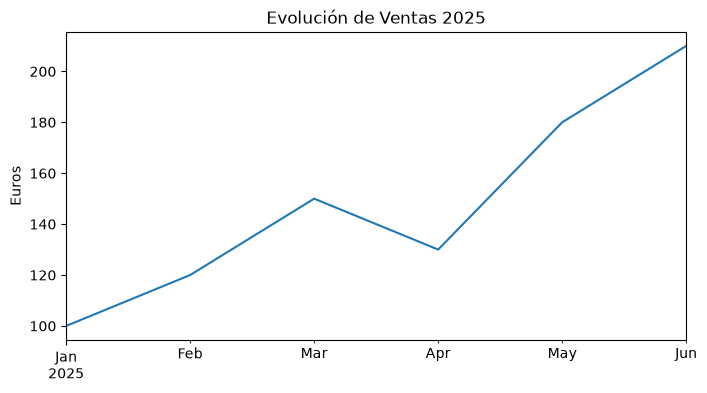

In [69]:
# Crear un DataFrame para serie temporal
df_ventas = pd.DataFrame({
    "Ventas": [100, 120, 150, 130, 180, 210]
}, index=pd.date_range(start="2025-01-01", periods=6, freq="ME"))

# 1. Gráfico de líneas (Serie temporal)
df_ventas["Ventas"].plot(kind="line", title="Evolución de Ventas 2025", figsize=(8, 4))
plt.ylabel("Euros")
plt.show()

# 2. Tipos de gráficos habituales mediante el argumento 'kind':
# - kind='bar' o 'barh' : Gráficos de barras (comparaciones de categorías)
# - kind='hist'         : Histogramas (distribución de variables continuas)
# - kind='box'          : Diagrama de caja (detección de atípicos / outliers)
# - kind='scatter'      : Gráfico de dispersión (relación entre dos variables x e y)

Ideas clave

* Parsing explícito: Convertir columnas de texto a datetime64 con to_datetime() habilita la aritmética de fechas (restar fechas para calcular duraciones o plazos) y la alineación temporal.
* Accesor .dt: Evita escribir bucles for para extraer partes de una fecha; aplica la transformación de forma vectorial sobre toda la Serie.
* resample vs groupby: resample() requiere que el índice sea de tipo datetime y está optimizado exclusivamente para agrupamientos por intervalos cronológicos.
* Visualización exploratoria: El método .plot() de Pandas busca la inspección veloz del analista; para gráficos finales listos para presentación o publicación se suele pasar al Tema IV utilizando Seaborn o Matplotlib directamente.
___